In [1]:
%%capture
!pip install roboflow

In [2]:
import os
import re
import glob
import time
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from roboflow import Roboflow
import matplotlib.pyplot as plt
from huggingface_hub import notebook_login

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

In [3]:
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("tyler-yonjx").project("car-colors-1smyc")
version = project.version(5)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Colors-5 in folder:: 100%|██████████| 2036/2036 [00:00<00:00, 2772.08it/s]


In [4]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [5]:
class ClassificationDataLoader:
    def __init__(self, data_dir, batch_size, image_size, partition, augment=True,
                 prefetch=tf.data.AUTOTUNE, shuffle_buffer=1000):
        """
        TensorFlow DataLoader para clasificación de imágenes.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            batch_size: Tamaño del batch
            image_size: Tupla (height, width) para redimensionar imágenes
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
            prefetch: Número de batches a prefetch (default: AUTOTUNE)
            shuffle_buffer: Tamaño del buffer para shuffle
        """
        self.data_dir = Path(data_dir)
        self.batch_size = batch_size
        self.image_size = image_size
        self.partition = partition
        self.augment = augment and (partition.lower() == 'train')
        self.prefetch = prefetch
        self.shuffle_buffer = shuffle_buffer

        # Cargar estructura de clases
        partition_path = self.data_dir / self.partition
        self.class_folders = sorted([d for d in partition_path.iterdir() if d.is_dir()])
        self.class_to_idx = {cls.name: idx for idx, cls in enumerate(self.class_folders)}
        self.num_classes = len(self.class_folders)

        # Recolectar samples
        self.samples = []
        self.labels = []

        supported_formats = ['*.png', '*.jpg', '*.jpeg']

        for class_folder in tqdm(self.class_folders, desc="Loading dataset"):
            class_idx = self.class_to_idx[class_folder.name]
            for format_pattern in supported_formats:
                files = glob.glob(str(class_folder / format_pattern))
                for file_path in files:
                    self.samples.append(file_path)
                    self.labels.append(class_idx)

        # Ordenar alfabéticamente
        sorted_pairs = sorted(zip(self.samples, self.labels),
                            key=lambda pair: self._alphanumeric_key(pair[0]))
        self.samples, self.labels = zip(*sorted_pairs)
        self.samples = list(self.samples)
        self.labels = list(self.labels)

        self.num_samples = len(self.samples)
        print(f"Found {self.num_samples} images across {self.num_classes} classes in {partition}")

        # Guardar mapeo de clases
        if partition.lower() == 'train':
            with open('class_mapping.txt', 'w') as f:
                f.write("Class Name -> Label Index\n")
                f.write("-" * 30 + "\n")
                for class_name, idx in sorted(self.class_to_idx.items(), key=lambda x: x[1]):
                    f.write(f"{class_name} -> {idx}\n")
            print(f"Class mapping saved to class_mapping.txt")

        # Crear dataset
        self.dataset = self._build_dataset()

    @staticmethod
    def _alphanumeric_key(s):
        """Clave para ordenamiento alfanumérico natural"""
        return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', s)]

    def _load_and_preprocess_image(self, file_path, label):
        """Carga y preprocesa una imagen"""
        # Leer imagen
        img = tf.io.read_file(file_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])

        # Redimensionar
        img = tf.image.resize(img, self.image_size)

        # Normalizar a [0, 1]
        img = tf.cast(img, tf.float32) / 255.0

        return img, label

    def _augment_image(self, image, label):
        """Aplica data augmentation"""
        # Horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)

        # Vertical flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_up_down(image)

        # Brightness
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_brightness(image, 0.2)

        # Contrast
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_contrast(image, 0.8, 1.2)

        # Saturation
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_saturation(image, 0.8, 1.2)

        # Gaussian noise
        if tf.random.uniform(()) > 0.7:
            noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
            image = image + noise

        # Clip values
        image = tf.clip_by_value(image, 0.0, 1.0)

        return image, label

    def _build_dataset(self):
        """Construye el pipeline de tf.data"""
        # Crear dataset desde listas
        dataset = tf.data.Dataset.from_tensor_slices((self.samples, self.labels))

        # Shuffle si es train
        if self.partition.lower() == 'train':
            dataset = dataset.shuffle(buffer_size=self.shuffle_buffer,
                                     reshuffle_each_iteration=True)

        # Cargar y preprocesar imágenes
        dataset = dataset.map(self._load_and_preprocess_image,
                             num_parallel_calls=tf.data.AUTOTUNE)

        # Aplicar augmentation si corresponde
        if self.augment:
            dataset = dataset.map(self._augment_image,
                                 num_parallel_calls=tf.data.AUTOTUNE)

        # Batch y prefetch
        dataset = dataset.batch(self.batch_size)
        dataset = dataset.prefetch(self.prefetch)

        return dataset

    def __len__(self):
        """Retorna el número de batches"""
        return (self.num_samples + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        """Permite iterar sobre el dataset"""
        return iter(self.dataset)

    def get_dataset(self):
        """Retorna el tf.data.Dataset"""
        return self.dataset

In [6]:
# Crear dataloader para entrenamiento
train_loader = ClassificationDataLoader(
    data_dir='./Car-Colors-5',
    batch_size=32,
    image_size=(224, 224),
    partition='train',
    augment=True
)

# Crear dataloader para validación
val_loader = ClassificationDataLoader(
    data_dir='./Car-Colors-5',
    batch_size=32,
    image_size=(224, 224),
    partition='valid',
    augment=False
)

# Crear dataloader para evaluación
test_loader = ClassificationDataLoader(
    data_dir='./Car-Colors-5',
    batch_size=32,
    image_size=(224, 224),
    partition='test',
    augment=False
)

Loading dataset: 100%|██████████| 9/9 [00:00<00:00, 471.36it/s]


Found 1396 images across 9 classes in train
Class mapping saved to class_mapping.txt


Loading dataset: 100%|██████████| 9/9 [00:00<00:00, 1560.38it/s]


Found 395 images across 9 classes in valid


Loading dataset: 100%|██████████| 9/9 [00:00<00:00, 866.53it/s]

Found 213 images across 9 classes in test


In [7]:
class ResidualBlock(layers.Layer):
    """Bloque residual con skip connection"""
    def __init__(self, filters, stride=1, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.filters = filters
        self.stride = stride

        # Convoluciones principales
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)
        self.bn2 = layers.BatchNormalization()

        # Skip connection (si cambia dimensión)
        self.use_projection = stride != 1
        if self.use_projection:
            self.shortcut_conv = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)
            self.shortcut_bn = layers.BatchNormalization()

    def call(self, inputs, training=False):
        # Rama principal
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        # Skip connection
        if self.use_projection:
            shortcut = self.shortcut_conv(inputs)
            shortcut = self.shortcut_bn(shortcut, training=training)
        else:
            shortcut = inputs

        # Suma y activación
        x = layers.add([x, shortcut])
        x = tf.nn.relu(x)

        return x


class ClassificationModel(Model):
    """
    Modelo de clasificación con arquitectura ResNet simplificada
    Complejidad media: ~5-10M parámetros dependiendo de num_classes
    """
    def __init__(self, num_classes, dropout_rate=0.3, **kwargs):
        super(ClassificationModel, self).__init__(**kwargs)

        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        # Stem (entrada)
        self.conv1 = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.relu = layers.Activation('relu')
        self.maxpool = layers.MaxPooling2D(3, strides=2, padding='same')

        # Bloques residuales
        self.block1_1 = ResidualBlock(64, stride=1)
        self.block1_2 = ResidualBlock(64, stride=1)

        self.block2_1 = ResidualBlock(128, stride=2)
        self.block2_2 = ResidualBlock(128, stride=1)

        self.block3_1 = ResidualBlock(256, stride=2)
        self.block3_2 = ResidualBlock(256, stride=1)

        self.block4_1 = ResidualBlock(512, stride=2)
        self.block4_2 = ResidualBlock(512, stride=1)

        # Clasificador
        self.global_pool = layers.GlobalAveragePooling2D()
        self.dropout = layers.Dropout(dropout_rate)
        self.fc = layers.Dense(num_classes)
        self.softmax = layers.Softmax()

    def call(self, inputs, training=False):
        # Stem
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu(x)
        x = self.maxpool(x)

        # Bloques residuales
        x = self.block1_1(x, training=training)
        x = self.block1_2(x, training=training)

        x = self.block2_1(x, training=training)
        x = self.block2_2(x, training=training)

        x = self.block3_1(x, training=training)
        x = self.block3_2(x, training=training)

        x = self.block4_1(x, training=training)
        x = self.block4_2(x, training=training)

        # Clasificador
        x = self.global_pool(x)
        x = self.dropout(x, training=training)
        x = self.fc(x)
        x = self.softmax(x)

        return x


def create_classification_model(num_classes, input_shape=(224, 224, 3),
                                dropout_rate=0.3, learning_rate=1e-3):
    """
    Función helper para crear y compilar el modelo

    Args:
        num_classes: Número de clases a clasificar
        input_shape: Shape de entrada (height, width, channels)
        dropout_rate: Tasa de dropout (0.0 - 0.5)
        learning_rate: Learning rate para el optimizador

    Returns:
        Modelo compilado listo para entrenar
    """
    # Crear input explícito
    inputs = keras.Input(shape=input_shape)

    # Crear modelo
    model = ClassificationModel(
        num_classes=num_classes,
        dropout_rate=dropout_rate
    )

    # Conectar input con modelo
    outputs = model(inputs, training=False)

    # Crear modelo funcional
    full_model = keras.Model(inputs=inputs, outputs=outputs, name='ClassificationModel')

    return full_model

In [8]:
model = create_classification_model(
        num_classes=9,
        input_shape=(224,224,3),
        dropout_rate=0.1)

In [9]:
# Crear el learning rate scheduler exponencial
initial_learning_rate = 1e-3
decay_steps = 1000  # Cada cuántos steps decae
decay_rate = 0.96   # Factor de decaimiento (0.96 = reduce 4% cada decay_steps)

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True  # True = decaimiento escalonado, False = continuo
)

In [10]:
model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule if lr_schedule else 1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
                keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')])

In [11]:
model.summary(expand_nested=True)

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 9)              │    11,190,729 │
│ (ClassificationModel)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 112, 112, 64)   │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization        │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ activation (Activation)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d              │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block             │ ?                      │        74,240 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_1           │ ?                      │        74,240 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_2           │ ?                      │       230,912 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_3           │ ?                      │       295,936 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_4           │ ?                      │       920,576 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_5           │ ?                      │     1,181,696 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_6           │ ?                      │     3,676,160 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ residual_block_7           │ ?                      │     4,722,688 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ global_average_pooling2d   │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout (Dropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 9)              │         4,617 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ softmax (Softmax)          │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,190,729 (42.69 MB)

 Trainable params: 11,181,129 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [12]:
history = model.fit(
    train_loader.get_dataset(),
    validation_data=val_loader.get_dataset(),
    epochs=40,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )])

Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.2992 - loss: 2.4116 - top5_accuracy: 0.7943
Epoch 1: val_accuracy improved from -inf to 0.15949, saving model to best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 498ms/step - accuracy: 0.3008 - loss: 2.4002 - top5_accuracy: 0.7959 - val_accuracy: 0.1595 - val_loss: 4.5909 - val_top5_accuracy: 0.5823
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5214 - loss: 1.3193 - top5_accuracy: 0.9451
Epoch 2: val_accuracy improved from 0.15949 to 0.24304, saving model to best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.5222 - loss: 1.3186 - top5_accuracy: 0.9453 - val_accuracy: 0.2430 - val_loss: 2.3188 - val_top5_accuracy: 0.7266
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5354 - loss: 1.3593 - top5_accuracy: 0.9473
Epoch 3: val_accuracy did not improve from 0.24304
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.5362 - loss: 1.3568 - top5_accuracy: 0.9475 - val_

In [13]:
def plot_detailed_history(history, save_path='detailed_history.png'):
    """
    Grafica el historial con más detalle (incluye top-5 accuracy si está disponible)

    Args:
        history: Objeto History retornado por model.fit()
        save_path: Ruta donde guardar la imagen
    """
    # Verificar qué métricas están disponibles
    available_metrics = list(history.history.keys())
    has_top5 = 'top5_accuracy' in available_metrics

    # Determinar número de subplots
    n_plots = 3 if has_top5 else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))

    if n_plots == 2:
        ax1, ax2 = axes
    else:
        ax1, ax2, ax3 = axes

    epochs = range(1, len(history.history['loss']) + 1)

    # Plot 1: Loss
    ax1.plot(epochs, history.history['loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax1.plot(epochs, history.history['val_loss'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax1.set_title('Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy
    ax2.plot(epochs, history.history['accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax2.plot(epochs, history.history['val_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Top-5 Accuracy (si está disponible)
    if has_top5:
        ax3.plot(epochs, history.history['top5_accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
        ax3.plot(epochs, history.history['val_top5_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
        ax3.set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch', fontsize=12)
        ax3.set_ylabel('Top-5 Accuracy', fontsize=12)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Detailed history plot saved to {save_path}")
    plt.show()

Detailed history plot saved to detailed_history.png


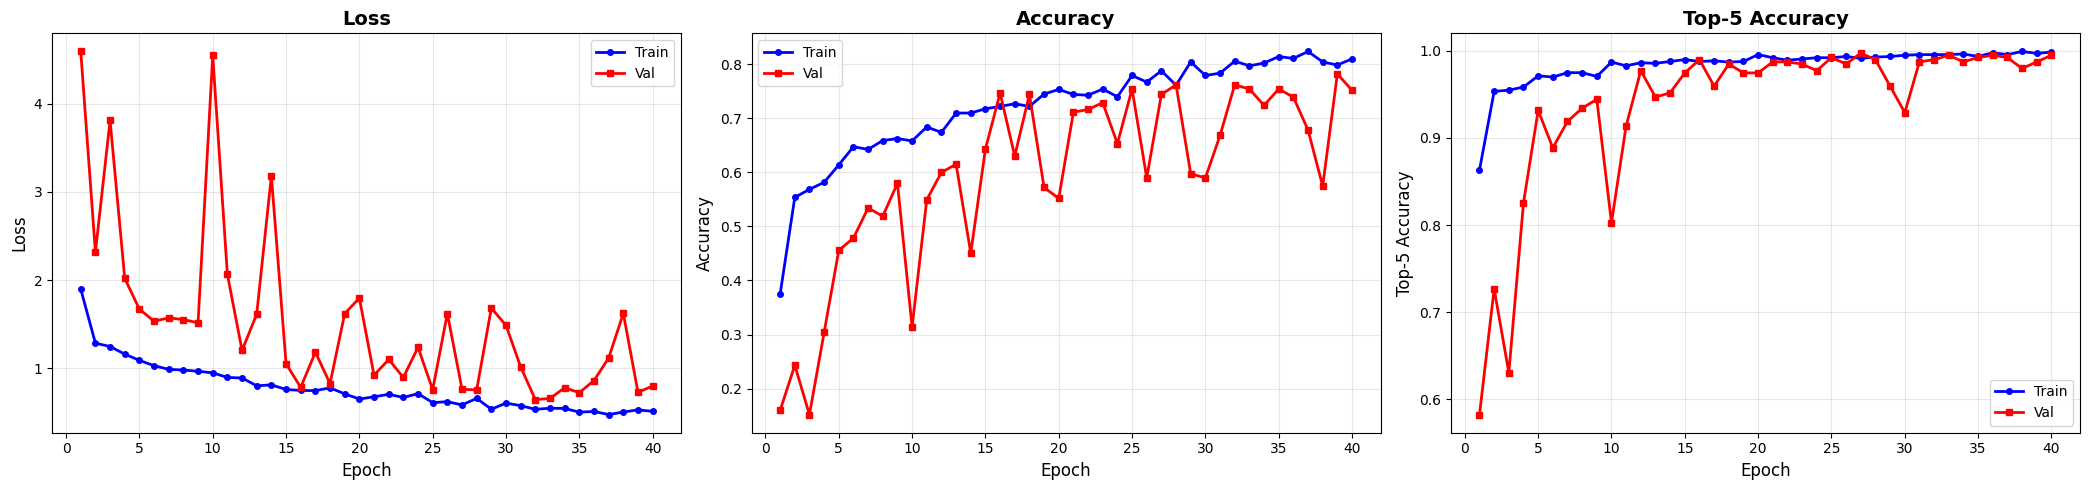

In [14]:
# Graficar historial detallado (incluye top-5 si está disponible)
plot_detailed_history(history)

In [15]:
class TFLiteConverter:
    """Clase para convertir y evaluar modelos TFLite con diferentes cuantizaciones"""

    def __init__(self, model, test_dataset, model_name='model'):
        """
        Args:
            model: Modelo de Keras entrenado
            test_dataset: Dataset de prueba (tf.data.Dataset)
            model_name: Nombre base para guardar los modelos
        """
        self.model = model
        self.test_dataset = test_dataset
        self.model_name = model_name
        self.results = {}

    def representative_dataset_gen(self):
        """Generador de dataset representativo para cuantización INT8"""
        # Tomar 100 muestras del dataset de prueba
        for images, _ in self.test_dataset.unbatch().batch(1).take(100):
            yield [tf.cast(images, tf.float32)]

    def convert_to_tflite_float32(self):
        """Convierte el modelo a TFLite Float32 (sin cuantización)"""
        print("\n" + "="*60)
        print("Convirtiendo a TFLite Float32...")
        print("="*60)

        converter = tf.lite.TFLiteConverter.from_keras_model(self.model)
        # Especificar explícitamente float32 para entrada y salida
        converter.inference_input_type = tf.float32
        converter.inference_output_type = tf.float32
        tflite_model = converter.convert()

        # Guardar modelo
        model_path = f'{self.model_name}_float32.tflite'
        with open(model_path, 'wb') as f:
            f.write(tflite_model)

        print(f"Modelo guardado en {model_path}")
        return tflite_model, model_path

    def convert_to_tflite_float16(self):
        """Convierte el modelo a TFLite Float16"""
        print("\n" + "="*60)
        print("Convirtiendo a TFLite Float16...")
        print("="*60)

        converter = tf.lite.TFLiteConverter.from_keras_model(self.model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
        # Float16 usa float32 para entrada/salida, float16 internamente
        converter.inference_input_type = tf.float32
        converter.inference_output_type = tf.float32
        tflite_model = converter.convert()

        # Guardar modelo
        model_path = f'{self.model_name}_float16.tflite'
        with open(model_path, 'wb') as f:
            f.write(tflite_model)

        print(f"Modelo guardado en {model_path}")
        return tflite_model, model_path

    def convert_to_tflite_dynamic_quant(self):
        """Convierte el modelo a TFLite con cuantización dinámica"""
        print("\n" + "="*60)
        print("Convirtiendo a TFLite con Cuantización Dinámica...")
        print("="*60)

        converter = tf.lite.TFLiteConverter.from_keras_model(self.model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        # Dynamic quant usa float32 para entrada/salida, int8 internamente
        converter.inference_input_type = tf.float32
        converter.inference_output_type = tf.float32
        tflite_model = converter.convert()

        # Guardar modelo
        model_path = f'{self.model_name}_dynamic_quant.tflite'
        with open(model_path, 'wb') as f:
            f.write(tflite_model)

        print(f"Modelo guardado en {model_path}")
        return tflite_model, model_path

    def convert_to_tflite_int8(self):
        """Convierte el modelo a TFLite INT8 (cuantización completa)"""
        print("\n" + "="*60)
        print("Convirtiendo a TFLite INT8...")
        print("="*60)

        converter = tf.lite.TFLiteConverter.from_keras_model(self.model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = self.representative_dataset_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        # INT8 usa uint8 para entrada y salida
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
        tflite_model = converter.convert()

        # Guardar modelo
        model_path = f'{self.model_name}_int8.tflite'
        with open(model_path, 'wb') as f:
            f.write(tflite_model)

        print(f"Modelo guardado en {model_path}")
        return tflite_model, model_path

    def evaluate_tflite_model(self, model_path, model_type):
        """
        Evalúa un modelo TFLite

        Args:
            model_path: Ruta al modelo .tflite
            model_type: Tipo de modelo ('float32', 'float16', 'dynamic', 'int8')
        """
        print(f"\nEvaluando modelo {model_type}...")

        # Cargar modelo TFLite
        interpreter = tf.lite.Interpreter(model_path=model_path)
        interpreter.allocate_tensors()

        # Obtener detalles de entrada/salida
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # Obtener dtype de entrada y salida
        input_dtype = input_details[0]['dtype']
        output_dtype = output_details[0]['dtype']

        print(f"  Input dtype: {input_dtype}")
        print(f"  Output dtype: {output_dtype}")

        # Obtener información del modelo
        model_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
        num_ops = len(interpreter.get_tensor_details())

        # Preparar para evaluación
        correct_predictions = 0
        top5_correct = 0
        total_samples = 0
        inference_times = []
        total_loss = 0.0

        # Evaluar en todo el dataset de prueba
        for images, labels in self.test_dataset:
            for i in range(images.shape[0]):
                image = images[i:i+1].numpy()
                label = labels[i].numpy()

                # Preprocesar según dtype de entrada del modelo
                if input_dtype == np.uint8:
                    # Para INT8: convertir [0, 1] a uint8 [0, 255]
                    # El modelo internamente maneja scale y zero_point
                    image = (image * 255.0).astype(np.uint8)
                elif input_dtype == np.float32:
                    # Para Float32/Float16/Dynamic: mantener como float32 [0, 1]
                    image = image.astype(np.float32)
                elif input_dtype == np.float16:
                    # Para Float16 (si se especificó): convertir a float16
                    image = image.astype(np.float16)
                else:
                    # Fallback: usar float32
                    image = image.astype(np.float32)

                # Inferencia con medición de tiempo
                start_time = time.perf_counter()
                interpreter.set_tensor(input_details[0]['index'], image)
                interpreter.invoke()
                output = interpreter.get_tensor(output_details[0]['index'])
                end_time = time.perf_counter()

                inference_times.append((end_time - start_time) * 1000)  # ms

                # Postprocesar salida según dtype de salida del modelo
                if output_dtype == np.uint8:
                    # Para INT8: convertir uint8 [0, 255] a float [0, 1]
                    # El modelo internamente ya aplicó scale y zero_point
                    output = output.astype(np.float32) / 255.0
                elif output_dtype == np.float32:
                    # Para Float32/Float16/Dynamic: ya está en float32
                    output = output.astype(np.float32)
                elif output_dtype == np.float16:
                    # Para Float16 (si se especificó): convertir a float32
                    output = output.astype(np.float32)
                else:
                    # Fallback: convertir a float32
                    output = output.astype(np.float32)

                # El modelo ya tiene softmax, output son probabilidades
                probs = output[0]

                # Calcular loss (sparse categorical crossentropy)
                epsilon = 1e-7
                loss = -np.log(np.clip(probs[label], epsilon, 1.0))
                total_loss += loss

                # Top-1 accuracy
                predicted_label = np.argmax(probs)
                if predicted_label == label:
                    correct_predictions += 1

                # Top-5 accuracy
                top5_predictions = np.argsort(probs)[-5:]
                if label in top5_predictions:
                    top5_correct += 1

                total_samples += 1

        # Calcular métricas
        accuracy = correct_predictions / total_samples
        top5_accuracy = top5_correct / total_samples
        avg_loss = total_loss / total_samples
        avg_inference_time = np.mean(inference_times)
        std_inference_time = np.std(inference_times)

        # Guardar resultados
        self.results[model_type] = {
            'model_path': model_path,
            'model_size_mb': model_size,
            'num_ops': num_ops,
            'input_dtype': str(input_dtype),
            'output_dtype': str(output_dtype),
            'accuracy': accuracy,
            'top5_accuracy': top5_accuracy,
            'loss': avg_loss,
            'avg_inference_time_ms': avg_inference_time,
            'std_inference_time_ms': std_inference_time,
            'total_samples': total_samples
        }

        print(f"Evaluación completa: Loss={avg_loss:.4f}, Accuracy={accuracy:.4f}, "
              f"Top-5={top5_accuracy:.4f}, Tiempo Promedio={avg_inference_time:.2f}ms")

        return self.results[model_type]

    def evaluate_keras_model(self):
        """Evalúa el modelo Keras original"""
        print("\n" + "="*60)
        print("Evaluando Modelo Keras Original...")
        print("="*60)

        # Evaluar con evaluate (devuelve loss y métricas)
        eval_results = self.model.evaluate(self.test_dataset, verbose=0)
        # eval_results = [loss, accuracy, top5_accuracy, ...]
        loss = eval_results[0]
        accuracy = eval_results[1] if len(eval_results) > 1 else 0.0
        top5_accuracy = eval_results[2] if len(eval_results) > 2 else 0.0

        # Medir tiempo de inferencia
        inference_times = []
        total_samples = 0

        for images, _ in self.test_dataset:
            for i in range(images.shape[0]):
                image = images[i:i+1]

                start_time = time.perf_counter()
                _ = self.model(image, training=False)
                end_time = time.perf_counter()

                inference_times.append((end_time - start_time) * 1000)  # ms
                total_samples += 1

        avg_inference_time = np.mean(inference_times)
        std_inference_time = np.std(inference_times)

        # Obtener tamaño del modelo (aproximado)
        self.model.save('temp_model.h5')
        model_size = os.path.getsize('temp_model.h5') / (1024 * 1024)  # MB
        os.remove('temp_model.h5')

        # Contar operaciones (capas)
        num_ops = sum([1 for layer in self.model.layers])

        self.results['keras_original'] = {
            'model_path': 'N/A (Keras)',
            'model_size_mb': model_size,
            'num_ops': num_ops,
            'input_dtype': 'float32',
            'output_dtype': 'float32',
            'accuracy': accuracy,
            'top5_accuracy': top5_accuracy,
            'loss': loss,
            'avg_inference_time_ms': avg_inference_time,
            'std_inference_time_ms': std_inference_time,
            'total_samples': total_samples
        }

        print(f"Evaluación completa: Loss={loss:.4f}, Accuracy={accuracy:.4f}, "
              f"Top-5={top5_accuracy:.4f}, Tiempo Promedio={avg_inference_time:.2f}ms")

        return self.results['keras_original']

    def convert_all(self):
        """Convierte el modelo a todos los formatos"""
        # Modelo original Keras
        self.evaluate_keras_model()

        # Float32
        _, float32_path = self.convert_to_tflite_float32()
        self.evaluate_tflite_model(float32_path, 'float32')

        # Float16
        _, float16_path = self.convert_to_tflite_float16()
        self.evaluate_tflite_model(float16_path, 'float16')

        # Dynamic Quantization
        _, dynamic_path = self.convert_to_tflite_dynamic_quant()
        self.evaluate_tflite_model(dynamic_path, 'dynamic_quant')

        # INT8
        _, int8_path = self.convert_to_tflite_int8()
        self.evaluate_tflite_model(int8_path, 'int8')

    def print_comparison_table(self):
        """Imprime tabla comparativa de todos los modelos"""
        print("\n" + "="*140)
        print("TABLA COMPARATIVA DE MODELOS")
        print("="*140)
        print(f"{'Tipo':<18} {'Tamaño (MB)':<13} {'Ops':<6} {'In/Out dtype':<20} {'Loss':<10} {'Acc':<10} "
              f"{'Top-5':<10} {'Tiempo (ms)':<13} {'Desv (ms)':<12}")
        print("-"*140)

        order = ['keras_original', 'float32', 'float16', 'dynamic_quant', 'int8']

        for model_type in order:
            if model_type in self.results:
                r = self.results[model_type]
                dtype_str = f"{r['input_dtype']}/{r['output_dtype']}"
                print(f"{model_type:<18} {r['model_size_mb']:<13.2f} {r['num_ops']:<6} "
                      f"{dtype_str:<20} {r['loss']:<10.4f} {r['accuracy']:<10.4f} "
                      f"{r['top5_accuracy']:<10.4f} {r['avg_inference_time_ms']:<13.2f} "
                      f"{r['std_inference_time_ms']:<12.2f}")

        print("="*140)

        # Comparaciones adicionales
        print("\nCONCLUSIONES CLAVE:")
        print("-"*140)

        if 'keras_original' in self.results and 'int8' in self.results:
            size_reduction = (1 - self.results['int8']['model_size_mb'] /
                            self.results['keras_original']['model_size_mb']) * 100
            speed_improvement = (self.results['keras_original']['avg_inference_time_ms'] /
                               self.results['int8']['avg_inference_time_ms'])
            accuracy_drop = (self.results['keras_original']['accuracy'] -
                           self.results['int8']['accuracy']) * 100
            loss_increase = (self.results['int8']['loss'] -
                           self.results['keras_original']['loss'])

            print(f"INT8 vs Keras Original:")
            print(f"  • Reducción de tamaño: {size_reduction:.1f}%")
            print(f"  • Mejora de velocidad: {speed_improvement:.2f}x")
            print(f"  • Caída de accuracy: {accuracy_drop:.2f}%")
            print(f"  • Incremento de loss: {loss_increase:.4f}")

        print("="*140)

In [16]:
converter = TFLiteConverter(model, test_loader.get_dataset(), 'my_classification_model')
converter.convert_all()
converter.print_comparison_table()


Evaluando Modelo Keras Original...


Evaluación completa: Loss=0.6187, Accuracy=0.7465, Top-5=1.0000, Tiempo Promedio=60.25ms

Convirtiendo a TFLite Float32...
Saved artifact at '/tmp/tmp2phev4gg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  138425163361040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163357584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163360656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163366032: TensorSpec(sha

    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    


Evaluación completa: Loss=0.6187, Accuracy=0.7465, Top-5=1.0000, Tiempo Promedio=61.53ms

Convirtiendo a TFLite Float16...
Saved artifact at '/tmp/tmpb2pjx_id'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  138425163361040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163357584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163360656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163366032: TensorSpec(sha

    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    


...

Evaluación completa: Loss=0.6215, Accuracy=0.7465, Top-5=0.9953, Tiempo Promedio=69.12ms

Convirtiendo a TFLite INT8...
Saved artifact at '/tmp/tmpedstg2fj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  138425163361040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163357584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163356624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163358352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163360656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138425163366032: TensorSpec(shape=

Statistics for quantized inputs were expected, but not specified; continuing anyway.


Modelo guardado en my_classification_model_int8.tflite

Evaluando modelo int8...
  Input dtype: <class 'numpy.uint8'>
  Output dtype: <class 'numpy.uint8'>


    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    


Evaluación completa: Loss=0.6229, Accuracy=0.7418, Top-5=0.9953, Tiempo Promedio=64.27ms

TABLA COMPARATIVA DE MODELOS
Tipo               Tamaño (MB)   Ops    In/Out dtype         Loss       Acc        Top-5      Tiempo (ms)   Desv (ms)   
--------------------------------------------------------------------------------------------------------------------------------------------
keras_original     128.16        2      float32/float32      0.6187     0.7465     1.0000     60.25         38.80       
float32            42.65         76     <class 'numpy.float32'>/<class 'numpy.float32'> 0.6187     0.7465     1.0000     61.53         15.61       
float16            21.34         118    <class 'numpy.float32'>/<class 'numpy.float32'> 0.6186     0.7465     1.0000     61.01         13.94       
dynamic_quant      10.74         76     <class 'numpy.float32'>/<class 'numpy.float32'> 0.6215     0.7465     0.9953     69.12         15.35       
int8               10.80         78     <class 'numpy.

In [18]:
notebook_login()

In [19]:
HF_USER = "liturriago"
SPACE_NAME = "ImageClassificationSpace"
REPO_URL = f"https://huggingface.co/spaces/{HF_USER}/{SPACE_NAME}"

In [20]:
!git clone {REPO_URL}

Cloning into 'ImageClassificationSpace'...
remote: Enumerating objects: 4, done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 4 (from 1)
Unpacking objects: 100% (4/4), 1.27 KiB | 1.27 MiB/s, done.


In [21]:
%cd {SPACE_NAME}
!git lfs track "*.keras"
!git lfs track "*.h5"
!git lfs track "*.pt"
!git lfs track "*.onnx"
!git lfs track "*.tflite"
!git lfs track "*.bin"
!git lfs track "*.safetensors"

!git add .gitattributes

/content/ImageClassificationSpace
Tracking "*.keras"
"*.h5" already supported
"*.pt" already supported
"*.onnx" already supported
"*.tflite" already supported
"*.bin" already supported
"*.safetensors" already supported


In [22]:
%cd ..

/content


In [24]:
!cp my_classification_model_float16.tflite {SPACE_NAME}/

In [25]:
%%writefile {SPACE_NAME}/app.py
from fastapi import FastAPI
from pydantic import BaseModel
import base64
import numpy as np
from PIL import Image
import io
import ai_edge_litert.interpreter as interpreter

app = FastAPI(title="AI Edge LiteRT API")

# Cargar el modelo TFLite una sola vez al iniciar
MODEL_PATH = "./my_classification_model_float16.tflite"  # Cambia según tu modelo (float32, float16, int8, etc.)
litert_interpreter = interpreter.Interpreter(model_path=MODEL_PATH)
litert_interpreter.allocate_tensors()

# Obtener detalles de entrada/salida
input_details = litert_interpreter.get_input_details()
output_details = litert_interpreter.get_output_details()

# Verificar si el modelo usa cuantización INT8
IS_INT8_MODEL = input_details[0]['dtype'] == np.uint8

class ImagePayload(BaseModel):
    image_base64: str

@app.get("/")
def home():
    return {
        "status": "ok",
        "message": "API is running! Use POST /predict",
        "model_info": {
            "input_shape": input_details[0]['shape'].tolist(),
            "input_dtype": str(input_details[0]['dtype']),
            "output_shape": output_details[0]['shape'].tolist(),
            "output_dtype": str(output_details[0]['dtype']),
            "quantized": IS_INT8_MODEL
        }
    }

def preprocess_image(img_bytes, target_size=(224, 224)):
    """
    Preprocesa la imagen usando NumPy y PIL

    Args:
        img_bytes: Bytes de la imagen
        target_size: Tupla (height, width)

    Returns:
        Imagen preprocesada como numpy array
    """
    # Decodificar imagen con PIL
    img = Image.open(io.BytesIO(img_bytes))

    # Convertir a RGB si es necesario
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Redimensionar
    img = img.resize(target_size, Image.BILINEAR)

    # Convertir a numpy array
    img_array = np.array(img, dtype=np.float32)

    # Normalizar a [0, 1]
    img_array = img_array / 255.0

    # Expandir dimensiones para batch
    img_array = np.expand_dims(img_array, axis=0)

    # Si es modelo INT8, convertir directamente a uint8 [0, 255]
    # El modelo internamente hace el escalado y zero point
    if IS_INT8_MODEL:
        # Volver a escala [0, 255] y convertir a uint8
        img_array = (img_array).astype(np.uint8)

    return img_array

def postprocess_output(output):
    """
    Postprocesa la salida del modelo

    Args:
        output: Salida raw del modelo

    Returns:
        Probabilidades como lista
    """
    # Si es modelo INT8, la salida ya está en uint8 [0, 255]
    # El modelo internamente hace el descalado, solo necesitamos
    # convertir de uint8 a float [0, 1] o [0, 255] dependiendo del caso
    if IS_INT8_MODEL:
        # Convertir de uint8 [0, 255] a float [0, 1]
        output = output.astype(np.float32)

    # El modelo ya tiene softmax, así que solo convertir a lista
    return output[0].tolist()

@app.post("/predict")
def predict(payload: ImagePayload):
    """
    Endpoint de predicción

    Args:
        payload: JSON con imagen en base64

    Returns:
        Predicciones del modelo
    """
    try:
        # Decodificar base64
        img_bytes = base64.b64decode(payload.image_base64)

        # Preprocesar imagen
        img_array = preprocess_image(img_bytes, target_size=(224, 224))

        # Inferencia con AI Edge LiteRT
        litert_interpreter.set_tensor(input_details[0]['index'], img_array)
        litert_interpreter.invoke()
        output = litert_interpreter.get_tensor(output_details[0]['index'])

        # Postprocesar salida
        predictions = postprocess_output(output)

        # Obtener clase predicha y confianza
        predicted_class = int(np.argmax(predictions))
        confidence = float(predictions[predicted_class])

        return {
            "prediction": predictions,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "top_5": sorted(
                [(i, float(p)) for i, p in enumerate(predictions)],
                key=lambda x: x[1],
                reverse=True
            )[:5]
        }

    except Exception as e:
        return {
            "error": str(e),
            "status": "failed"
        }

@app.get("/health")
def health_check():
    """Health check endpoint"""
    return {"status": "healthy", "model_loaded": True}

Writing ImageClassificationSpace/app.py


In [26]:
%%writefile {SPACE_NAME}/requirements.txt
fastapi
uvicorn[standard]
pydantic
numpy
pillow
ai-edge-litert

Writing ImageClassificationSpace/requirements.txt


In [27]:
%%writefile {SPACE_NAME}/runtime.txt
python-3.10

Writing ImageClassificationSpace/runtime.txt


In [28]:
%%writefile {SPACE_NAME}/README.md
---
title: ImageClassificationSpace
emoji: 🚀
colorFrom: blue
colorTo: purple
sdk: docker
pinned: false
---

# ClassificationVCAPI
API en HuggingFace Space con TensorFlow Serving-like pipeline.

Overwriting ImageClassificationSpace/README.md


In [29]:
%%writefile {SPACE_NAME}/Dockerfile
FROM python:3.10

# Crear usuario no-root
RUN useradd -m -u 1000 user
USER user
ENV PATH="/home/user/.local/bin:$PATH"

WORKDIR /app

COPY --chown=user ./requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r requirements.txt

COPY --chown=user . /app

EXPOSE 7860

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "7860"]

Writing ImageClassificationSpace/Dockerfile


In [30]:
!git config --global user.email "liturriago@unal.edu.co"
!git config --global user.name "liturriago"

In [31]:
%cd {SPACE_NAME}
!git add .
!git commit -m "ImageClassificationSpace\nAPI en HuggingFace Space con TensorFlow Serving-like pipeline."
!git push

/content/ImageClassificationSpace
[main f93586a] ImageClassificationSpace\nAPI en HuggingFace Space con TensorFlow Serving-like pipeline.
 7 files changed, 180 insertions(+), 4 deletions(-)
 create mode 100644 Dockerfile
 create mode 100644 app.py
 create mode 100644 my_classification_model_float16.tflite
 create mode 100644 requirements.txt
 create mode 100644 runtime.txt
Uploading LFS objects: 100% (1/1), 22 MB | 0 B/s, done.
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (9/9), 2.76 KiB | 2.76 MiB/s, done.
Total 9 (delta 1), reused 0 (delta 0), pack-reused 0
To https://huggingface.co/spaces/liturriago/ImageClassificationSpace
   85d7bbb..f93586a  main -> main


In [49]:
%cd ..

/content


In [50]:
import requests
import base64

# 1. Leer imagen
with open("./Car-Colors-5/test/Grey/8-1-1024x576_jpg.rf.e69d45f2abeb214a17cc72d86ced91bb.jpg", "rb") as f:
    img_bytes = f.read()

# 2. Convertir a base64
img_b64 = base64.b64encode(img_bytes).decode()

payload = {"image_base64": img_b64}

# 3. Enviar request
url = "https://liturriago-ImageClassificationSpace.hf.space/predict"
res = requests.post(url, json=payload)

print(res.json())

{'prediction': [0.01898542046546936, 0.03711516410112381, 0.01854613982141018, 0.5981765389442444, 0.01069015171378851, 0.008940087631344795, 0.2636195123195648, 0.04137619957327843, 0.002550683915615082], 'predicted_class': 3, 'confidence': 0.5981765389442444, 'top_5': [[3, 0.5981765389442444], [6, 0.2636195123195648], [7, 0.04137619957327843], [1, 0.03711516410112381], [0, 0.01898542046546936]]}
